<a href="https://colab.research.google.com/github/thegurdian/ML/blob/main/frank_without_smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
       Pregnancies      Glucose  BloodPressure  SkinThickness      Insulin  \
count  2000.000000  2000.000000    2000.000000    2000.000000  2000.000000   
mean      3.703500   121.182500      69.145500      20.935000    80.254000   
std

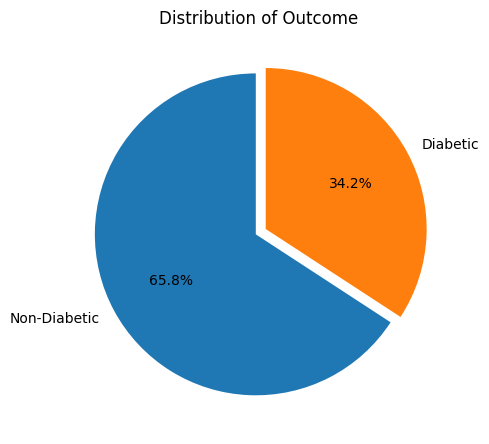

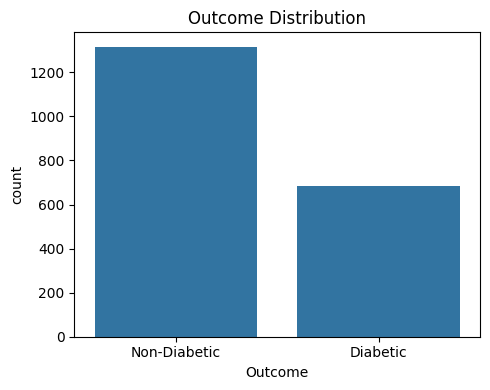


Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.458421
BMI                         0.276726
Age                         0.236509
Pregnancies                 0.224437
DiabetesPedigreeFunction    0.155459
Insulin                     0.120924
SkinThickness               0.076040
BloodPressure               0.075958
Name: Outcome, dtype: float64


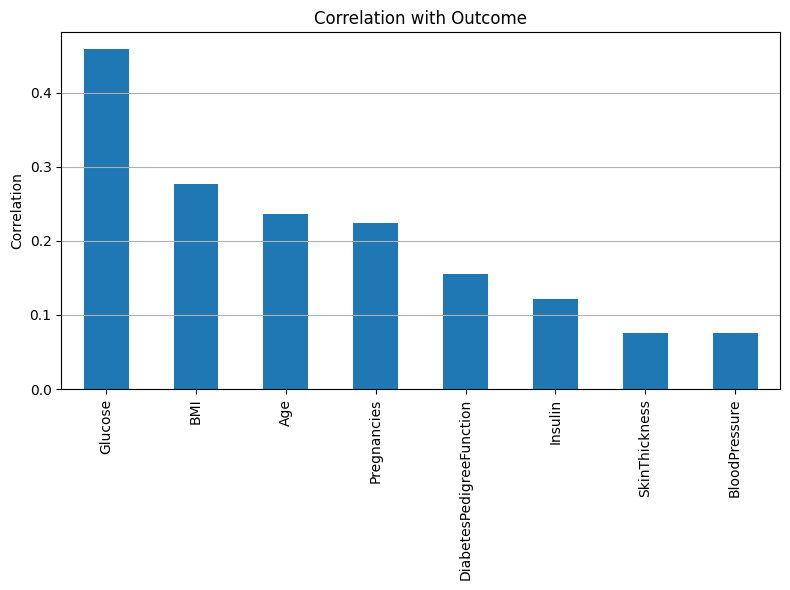


Zero counts in columns where 0 is not physiologically valid:
Glucose 13
BloodPressure 90
SkinThickness 573
Insulin 956
BMI 28


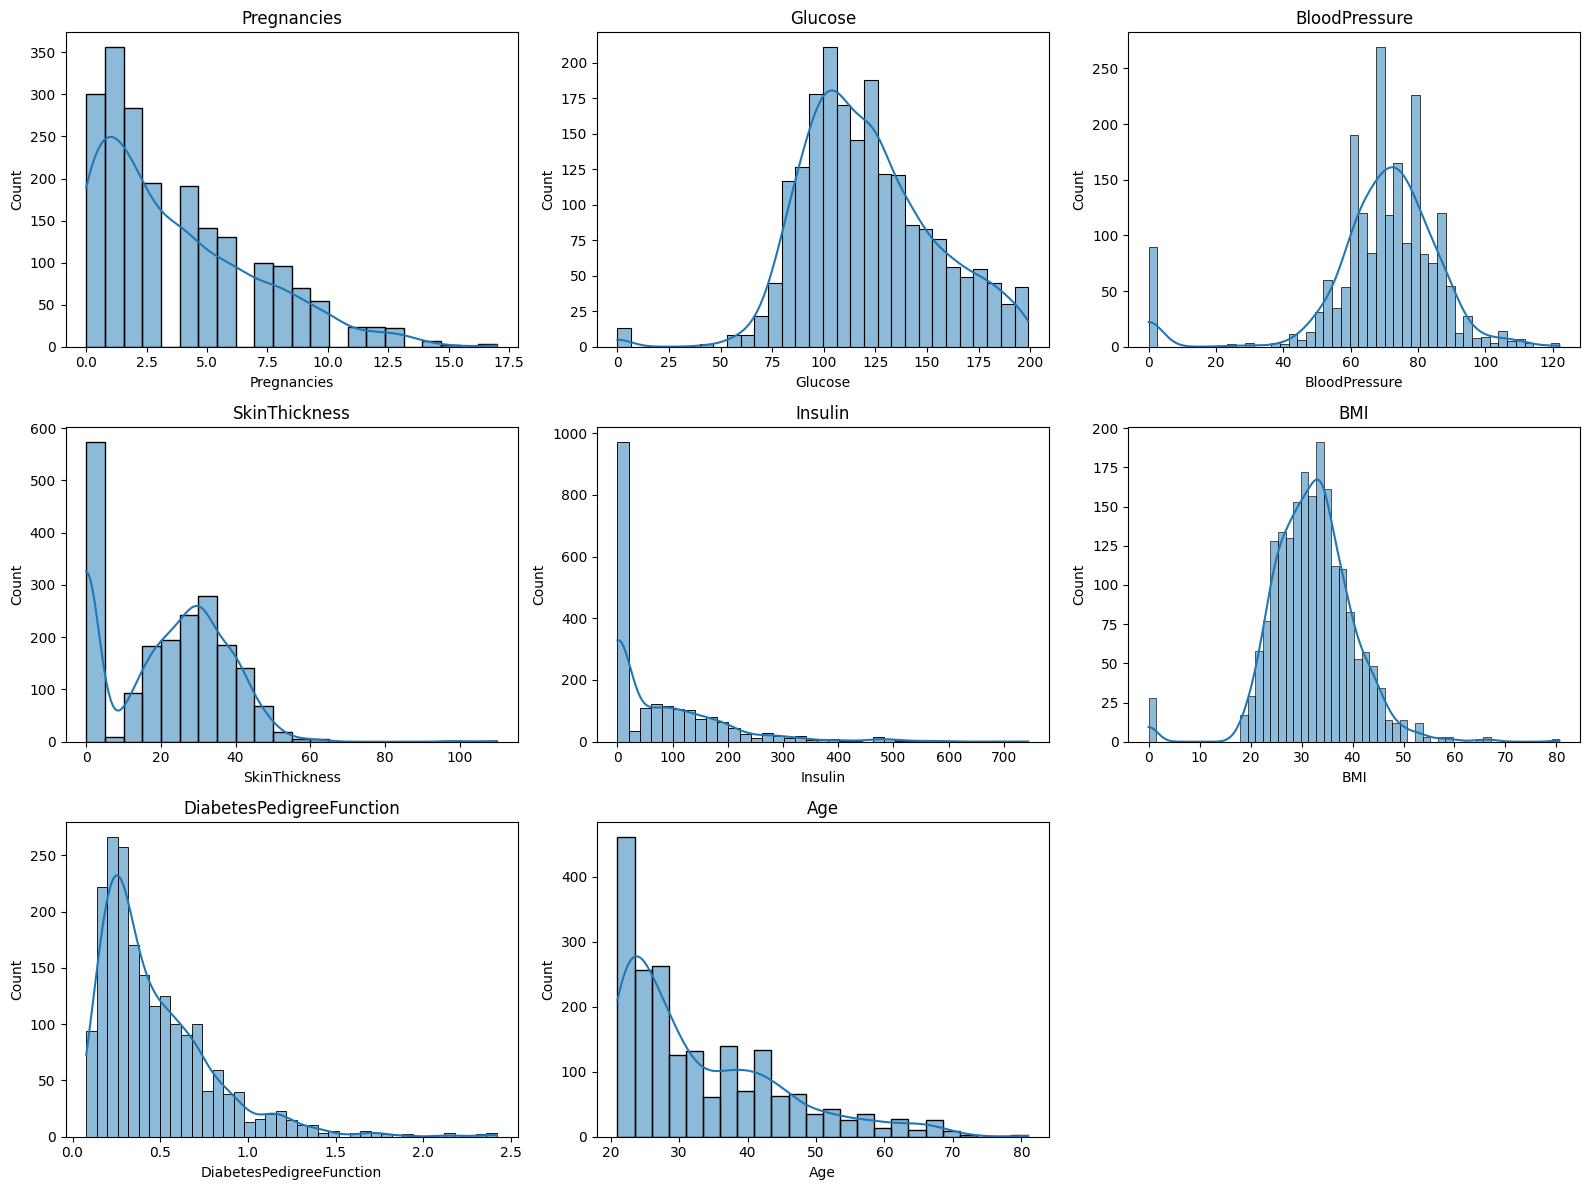

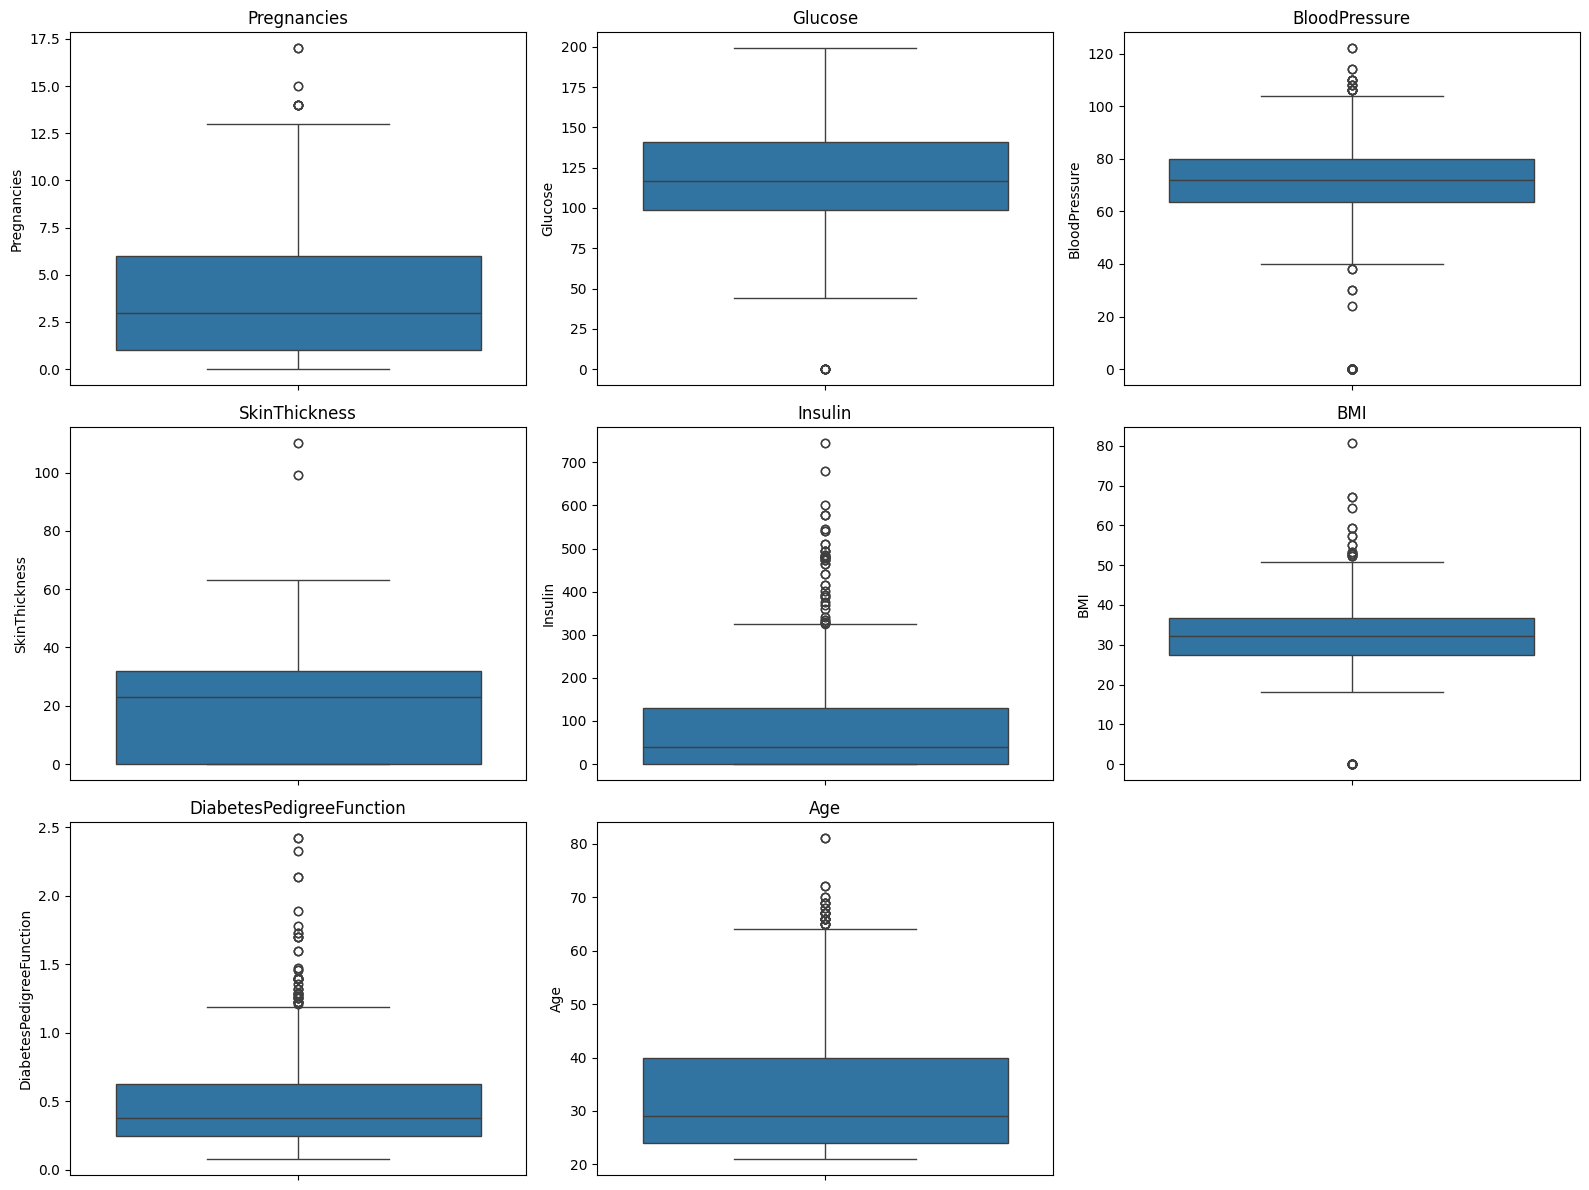

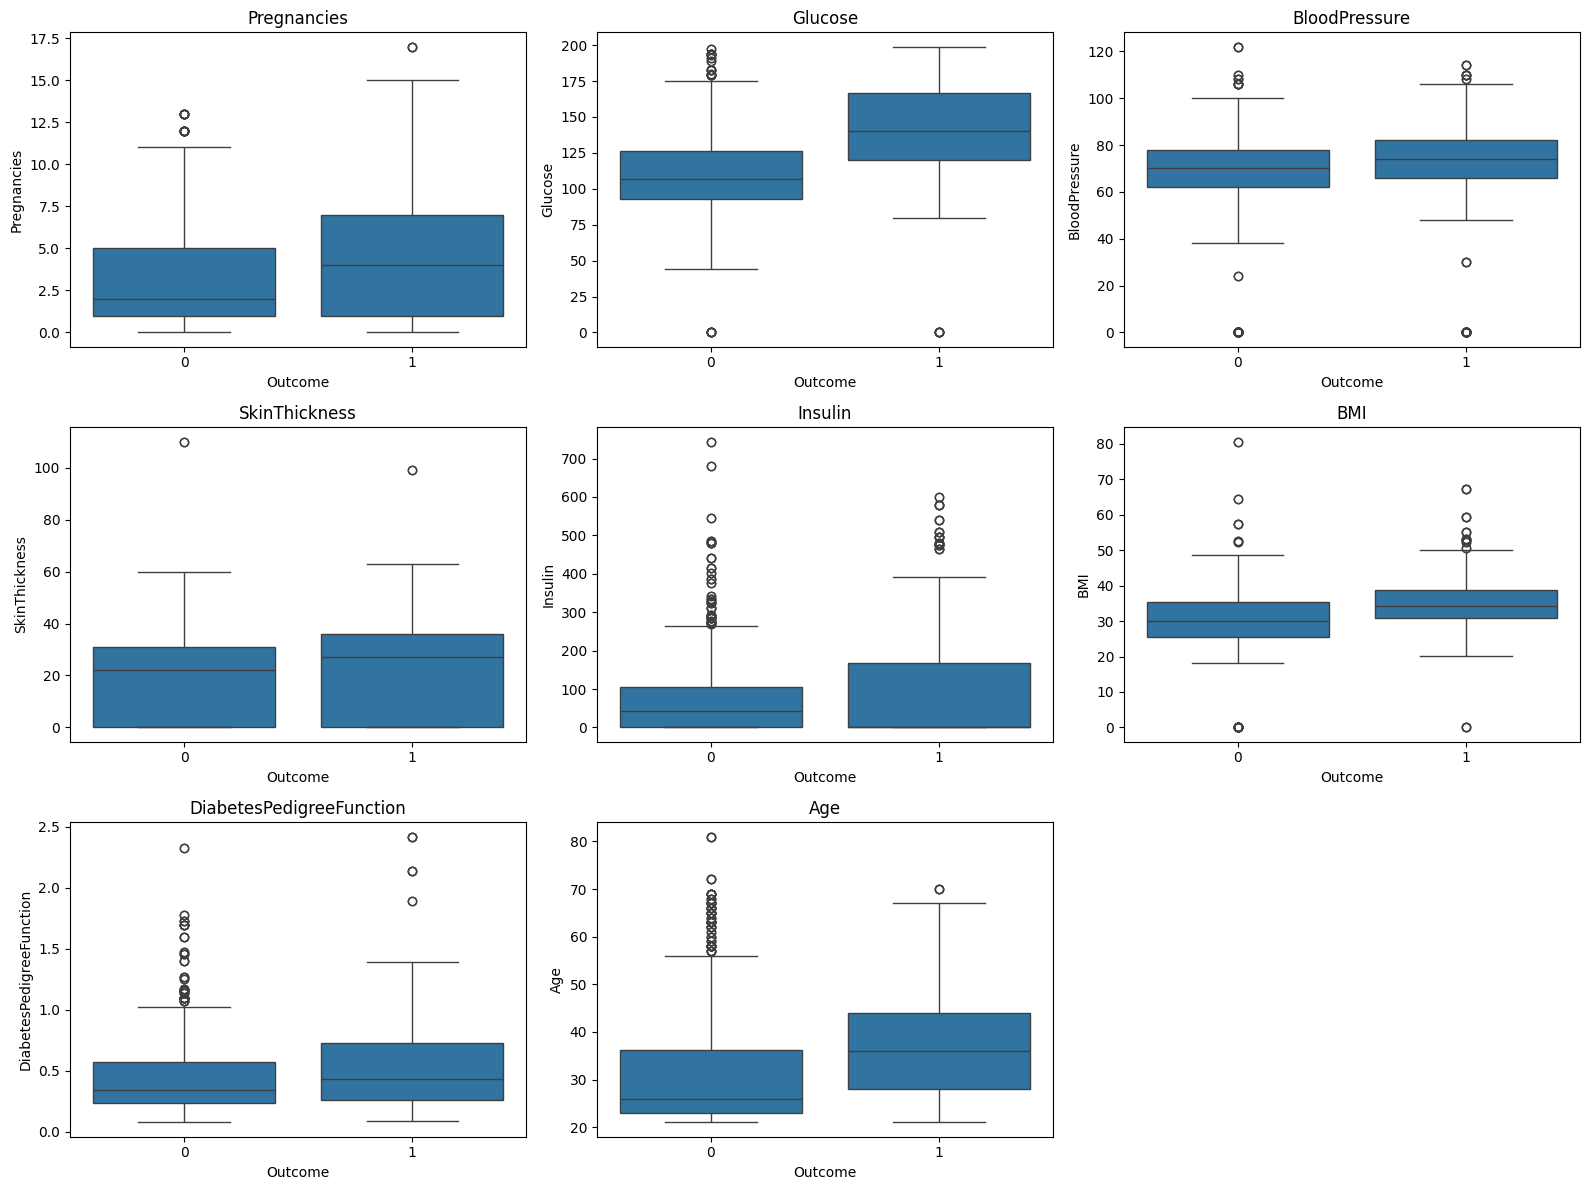

X_train: (1600, 8)
X_test : (400, 8)

Mutual Information (train set only):
                    Feature  Mutual Information
1                   Glucose            0.183429
6  DiabetesPedigreeFunction            0.176440
5                       BMI            0.152516
4                   Insulin            0.109517
3             SkinThickness            0.064677
7                       Age            0.059572
0               Pregnancies            0.048936
2             BloodPressure            0.006421


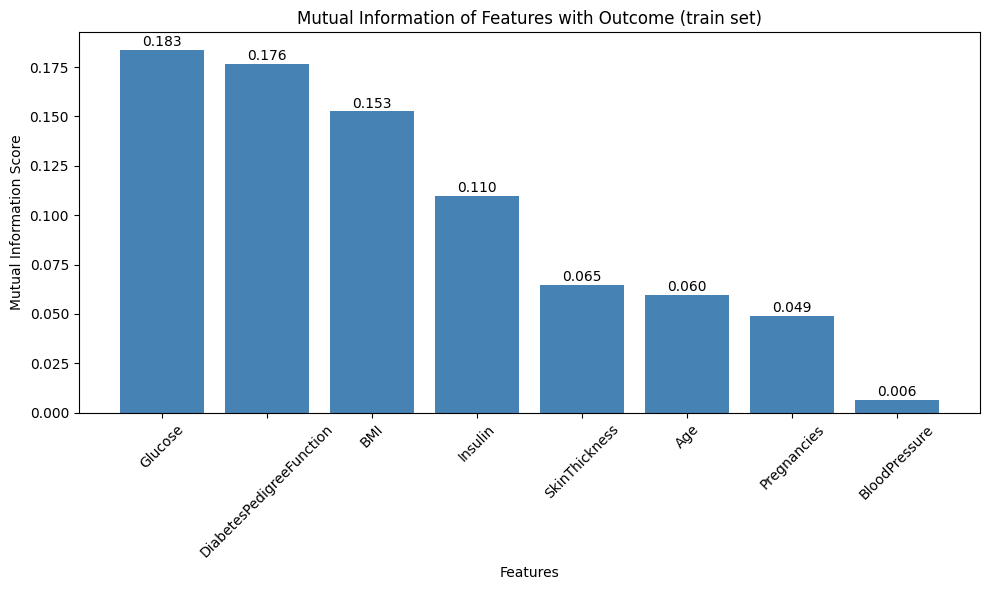


Logistic Regression
Accuracy : 79.75%
Precision: 75.45%
Recall   : 60.58%
F1-Score : 67.21%
Confusion Matrix:
[[236  27]
 [ 54  83]]
              precision    recall  f1-score   support

           0     0.8138    0.8973    0.8535       263
           1     0.7545    0.6058    0.6721       137

    accuracy                         0.7975       400
   macro avg     0.7842    0.7516    0.7628       400
weighted avg     0.7935    0.7975    0.7914       400


Decision Tree
Accuracy : 97.25%
Precision: 94.37%
Recall   : 97.81%
F1-Score : 96.06%
Confusion Matrix:
[[255   8]
 [  3 134]]
              precision    recall  f1-score   support

           0     0.9884    0.9696    0.9789       263
           1     0.9437    0.9781    0.9606       137

    accuracy                         0.9725       400
   macro avg     0.9660    0.9738    0.9697       400
weighted avg     0.9731    0.9725    0.9726       400


Random Forest
Accuracy : 96.75%
Precision: 95.59%
Recall   : 94.89%
F1-Score : 95.2

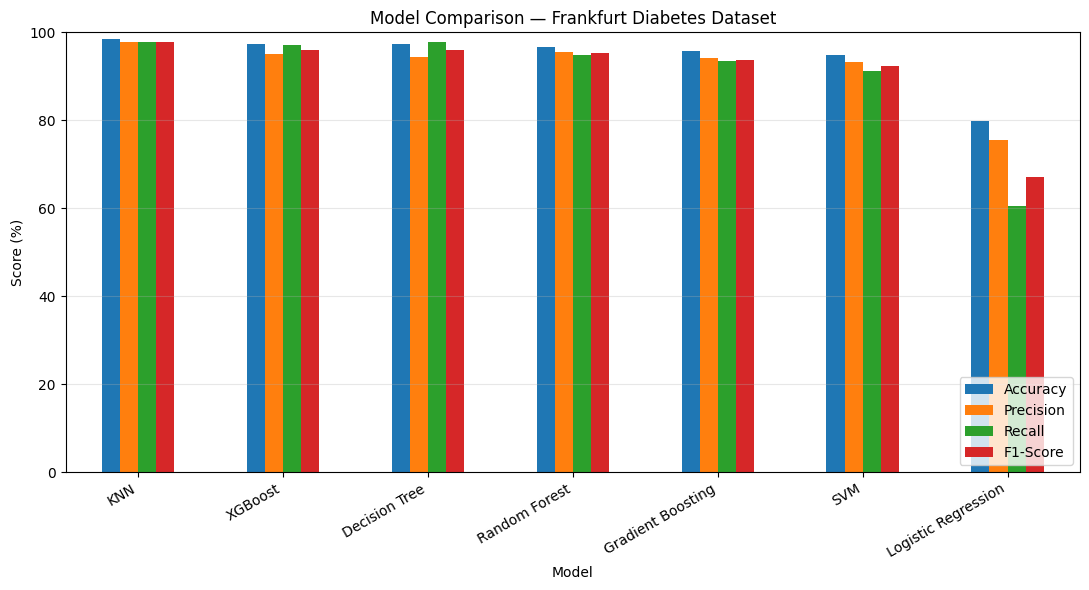

In [3]:
"""
Diabetes Prediction - Model Comparison (with EDA for research writeup)
Dataset: Frankfurt Hospital Diabetes Dataset (2000 patients, Germany)
Models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,
        XGBoost, KNN, SVM
Author: Mehedi

NOTE ON HOW THIS WAS MERGED
----------------------------
This combines your two scripts:
  - Script 1 (clean/fixed): correct order of operations — split BEFORE
    imputing/scaling, so there's no train/test leakage. This is why it gave
    the good, trustworthy numbers (XGBoost ~97% acc). That pipeline is left
    UNTOUCHED below.
  - Script 2 (Colab draft): had the EDA plots you want for your paper, but
    it computed the zero->median replacement and mutual information on the
    FULL dataset before splitting, which leaks test-set information into
    training. That's not safe for reported metrics, so it was not carried
    over as-is.

What changed: all plots from script 2 are kept, but moved to spots where
they can't leak information into the model:
  - Distribution / correlation / raw histograms & boxplots -> run on the
    raw data, before any cleaning decision is used by the model. These are
    purely descriptive (standard "Table 1 / Figure 1" style EDA for a paper)
    and don't affect training.
  - Mutual Information plot -> recomputed on X_train ONLY (after the split
    and after train-only imputation), instead of the full dataset. This is
    the leak-safe way to show feature relevance and is still a valid figure
    for your paper.
  - A model comparison bar chart was added at the end, since papers usually
    want a figure for the results table too.

Everything else (split, impute, scale, model definitions, metrics) is
IDENTICAL to script 1, so accuracy/precision/recall/F1 numbers will match
what you already got.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import xgboost as xgb

# ---------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------
DATA_PATH = "/content/frankfurt_diabetes_2000.csv"   # place this file next to the script
df = pd.read_csv(DATA_PATH)

df.info()
print(df.describe())

# NOTE: script 1 (the "fixed" pipeline) never drops duplicates, so we don't
# either here — doing so would change the row count/composition of the
# dataset before the split, which changes the train/test split itself and
# therefore the reported metrics. Dedup was in the Colab draft only.
print("\nMissing values (raw, before zero-cleaning):")
print(df.isnull().sum())

# ---------------------------------------------------------------
# 2. EDA / plots for the paper — descriptive only, computed on the
#    raw dataframe, so nothing here can leak into model training.
# ---------------------------------------------------------------

# 2a. Outcome distribution — pie chart
counts = df["Outcome"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=["Non-Diabetic", "Diabetic"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.02, 0.05),
)
plt.title("Distribution of Outcome")
plt.tight_layout()
plt.savefig("fig1_outcome_pie.png", dpi=200)
plt.show()

# 2b. Outcome distribution — count plot
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Outcome")
plt.xticks([0, 1], ["Non-Diabetic", "Diabetic"])
plt.title("Outcome Distribution")
plt.tight_layout()
plt.savefig("fig2_outcome_countplot.png", dpi=200)
plt.show()

# 2c. Correlation of raw features with Outcome
corr = df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)
print("\nCorrelation with Outcome:")
print(corr)

plt.figure(figsize=(8, 6))
corr.drop("Outcome").plot(kind="bar")
plt.ylabel("Correlation")
plt.title("Correlation with Outcome")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("fig3_correlation_bar.png", dpi=200)
plt.show()

# 2d. Biologically-impossible zeros — how many per column
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("\nZero counts in columns where 0 is not physiologically valid:")
for col in zero_check_cols:
    print(col, (df[col] == 0).sum())

# 2e. Feature distributions — histograms (raw, pre-cleaning)
features = df.drop("Outcome", axis=1).columns
plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.savefig("fig4_histograms.png", dpi=200)
plt.show()

# 2f. Feature distributions — boxplots (raw, pre-cleaning)
plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.savefig("fig5_boxplots.png", dpi=200)
plt.show()

# 2g. Feature distributions split by Outcome
plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Outcome", y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.savefig("fig6_boxplots_by_outcome.png", dpi=200)
plt.show()

# ---------------------------------------------------------------
# 3. Clean: these columns can't biologically be 0, so 0 = missing
#    (left as NaN here — imputed AFTER the split, using the train
#    set's median only, so the test set stays untouched)
# ---------------------------------------------------------------
cols_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for c in cols_zero_as_missing:
    df[c] = df[c].replace(0, np.nan)

X = df.drop(columns=['Outcome'])
y = df['Outcome']

# ---------------------------------------------------------------
# 4. Train/test split (stratified so class ratio is preserved)
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# ---------------------------------------------------------------
# 5. Impute missing values (median, fit on TRAIN only) then scale
# ---------------------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# ---------------------------------------------------------------
# 5b. Mutual Information plot — leak-safe version: computed on the
#     TRAIN split only, after train-only imputation. Descriptive
#     figure for the paper; does not feed back into model choice.
# ---------------------------------------------------------------
mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
mi_scores = pd.DataFrame({
    "Feature": X_train_imp.columns,
    "Mutual Information": mi
}).sort_values(by="Mutual Information", ascending=False)

print("\nMutual Information (train set only):")
print(mi_scores)

plt.figure(figsize=(10, 6))
plt.bar(mi_scores["Feature"], mi_scores["Mutual Information"], color="steelblue")
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Mutual Information of Features with Outcome (train set)")
for i, v in enumerate(mi_scores["Mutual Information"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig7_mutual_information.png", dpi=200)
plt.show()

# ---------------------------------------------------------------
# 6. Define models
#    (tree-based models don't need scaling, but scaled data works
#    fine for them too, so we use one consistent input for all)
# ---------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        criterion='entropy', max_depth=None, min_samples_leaf=1, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=10, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=3, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=21, weights='distance'),
    "SVM": SVC(kernel='rbf', C=300, gamma='scale', random_state=42),
}

# ---------------------------------------------------------------
# 7. Train, predict, evaluate
# ---------------------------------------------------------------
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1 * 100, 2),
    })

    print(f"\n{'=' * 50}")
    print(f"{name}")
    print(f"{'=' * 50}")
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"F1-Score : {f1 * 100:.2f}%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

# ---------------------------------------------------------------
# 8. Summary table, sorted by accuracy
# ---------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df.to_csv("model_comparison_results.csv", index=False)

print("\n\n" + "=" * 60)
print("SUMMARY - ALL MODELS")
print("=" * 60)
print(results_df.to_string(index=False))

# ---------------------------------------------------------------
# 9. Model comparison bar chart — handy figure for the results
#    section of the paper.
# ---------------------------------------------------------------
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
plot_df.plot(kind="bar", figsize=(11, 6))
plt.ylabel("Score (%)")
plt.title("Model Comparison — Frankfurt Diabetes Dataset")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig8_model_comparison.png", dpi=200)
plt.show()